<a href="https://colab.research.google.com/github/lktran1105/lktran1105.github.io/blob/main/MLDS_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import requests
import pandas as pd
from pprint import pprint
import time
import matplotlib.pyplot as plt

CLIMATE DATA

Importing Data

In [3]:
#Explore available datasets
url = "https://www.ncei.noaa.gov/cdo-web/api/v2/datasets"
headers = {
    "token": "NOAA_API_TOKEN"
}

response = requests.get(url, headers=headers)
print(response.status_code)
print(repr(response.text))

pprint(response.json())

200
'{"metadata":{"resultset":{"offset":1,"count":11,"limit":25}},"results":[{"uid":"gov.noaa.ncdc:C00861","mindate":"1763-01-01","maxdate":"2026-09-16","name":"Daily Summaries","datacoverage":1,"id":"GHCND"},{"uid":"gov.noaa.ncdc:C00946","mindate":"1763-01-01","maxdate":"2026-09-01","name":"Global Summary of the Month","datacoverage":1,"id":"GSOM"},{"uid":"gov.noaa.ncdc:C00947","mindate":"1763-01-01","maxdate":"2026-01-01","name":"Global Summary of the Year","datacoverage":1,"id":"GSOY"},{"uid":"gov.noaa.ncdc:C00345","mindate":"1991-06-05","maxdate":"2026-09-18","name":"Weather Radar (Level II)","datacoverage":0.95,"id":"NEXRAD2"},{"uid":"gov.noaa.ncdc:C00708","mindate":"1994-05-20","maxdate":"2026-09-17","name":"Weather Radar (Level III)","datacoverage":0.95,"id":"NEXRAD3"},{"uid":"gov.noaa.ncdc:C00821","mindate":"2010-01-01","maxdate":"2010-01-01","name":"Normals Annual/Seasonal","datacoverage":1,"id":"NORMAL_ANN"},{"uid":"gov.noaa.ncdc:C00823","mindate":"2010-01-01","maxdate":"2010

In [4]:
#Explore metadata of GSOM dataset
url = "https://www.ncei.noaa.gov/cdo-web/api/v2/datasets/GSOM"
headers = {
    "token": "API_TOKEN"
}

response = requests.get(url, headers=headers)
print(response.status_code)
print(repr(response.text))

pprint(response.json())

200
'{"mindate":"1763-01-01","maxdate":"2026-09-01","name":"Global Summary of the Month","datacoverage":1,"id":"GSOM"}'
{'datacoverage': 1,
 'id': 'GSOM',
 'maxdate': '2026-09-01',
 'mindate': '1763-01-01',
 'name': 'Global Summary of the Month'}


In [11]:
#Fetching data from dataset ID = GSOM
url = "https://www.ncei.noaa.gov/cdo-web/api/v2/data"
headers = {
    "token": "API_TOKEN"
}

base_params = {
    "datasetid": "GSOM", #global summary of the Month
    "locationid": "FIPS:AY", #location: Antartica
    "startdate": "2016-01-01",
    "enddate":"2026-01-01",
    "datatypeid": "TAVG" , #Average Temperateure
    "limit": "1000"


}

response = requests.get(url, headers=headers, params=base_params)
data = response.json()

print(response.status_code)
print(repr(response.text))

df = pd.DataFrame(data['results'])
df


200
'{"metadata":{"resultset":{"offset":1,"count":434,"limit":1000}},"results":[{"date":"2016-01-01T00:00:00","datatype":"TAVG","station":"GHCND:AYM00089004","attributes":",S","value":-7.82},{"date":"2016-01-01T00:00:00","datatype":"TAVG","station":"GHCND:AYM00089063","attributes":"8,S","value":0.4},{"date":"2016-01-01T00:00:00","datatype":"TAVG","station":"GHCND:AYM00089512","attributes":"3,S","value":-1.73},{"date":"2016-02-01T00:00:00","datatype":"TAVG","station":"GHCND:AYM00089004","attributes":",S","value":-9.69},{"date":"2016-03-01T00:00:00","datatype":"TAVG","station":"GHCND:AYM00089004","attributes":",S","value":-12.94},{"date":"2016-04-01T00:00:00","datatype":"TAVG","station":"GHCND:AYM00089004","attributes":"1,S","value":-15.46},{"date":"2016-05-01T00:00:00","datatype":"TAVG","station":"GHCND:AYM00089004","attributes":",S","value":-18.3},{"date":"2016-06-01T00:00:00","datatype":"TAVG","station":"GHCND:AYM00089004","attributes":"1,S","value":-25.08},{"date":"2016-06-01T00:00:0

,date,datatype,station,attributes,value
0,2016-01-01T00:00:00,TAVG,GHCND:AYM00089004,",S",-7.82
1,2016-01-01T00:00:00,TAVG,GHCND:AYM00089063,"8,S",0.40
2,2016-01-01T00:00:00,TAVG,GHCND:AYM00089512,"3,S",-1.73
3,2016-02-01T00:00:00,TAVG,GHCND:AYM00089004,",S",-9.69
4,2016-03-01T00:00:00,TAVG,GHCND:AYM00089004,",S",-12.94
...,...,...,...,...,...
429,2026-01-01T00:00:00,TAVG,GHCND:AYM00089577,",2",-38.14
430,2026-01-01T00:00:00,TAVG,GHCND:AYM00089606,"2,2",-32.68
431,2026-01-01T00:00:00,TAVG,GHCND:AYM00089659,",2",-18.20
432,2026-01-01T00:00:00,TAVG,GHCND:AYM00089661,"1,2",-4.93


Cleaning and Preparing Data

In [36]:
#Data Collection

raw = pd.read_csv("/content/gsom_antarctica.csv", index_col = 0)

#Raw data Snapshot
print(f"1. Number of rows: {len(raw)}")
print(f"2. Columns: {raw.columns.tolist()}")
print(f"3. Missing values: \n{raw.isnull().sum().to_string()}")
print("\nDATA BEFORE CLEANING")
print(raw.head(5))

1. Number of rows: 434
2. Columns: ['date', 'datatype', 'station', 'attributes', 'value']
3. Missing values: 
date          0
datatype      0
station       0
attributes    0
value         0

DATA BEFORE CLEANING
                  date datatype            station attributes  value
0  2016-01-01T00:00:00     TAVG  GHCND:AYM00089004         ,S  -7.82
1  2016-01-01T00:00:00     TAVG  GHCND:AYM00089063        8,S   0.40
2  2016-01-01T00:00:00     TAVG  GHCND:AYM00089512        3,S  -1.73
3  2016-02-01T00:00:00     TAVG  GHCND:AYM00089004         ,S  -9.69
4  2016-03-01T00:00:00     TAVG  GHCND:AYM00089004         ,S -12.94


In [80]:
#Data Cleaning

#Drop unnecessary columns
df_dropped = df.drop(columns=['datatype','station','attributes'], axis=1)

#Reformat the date column to only include date
df_dropped['date']=pd.to_datetime(df_dropped['date'])
df_dropped['date']=df['date'].dt.date

#Since there might be multiple station reporting temp for that month, we will
#group by month and year to have average region temp
df_by_month = df_dropped.groupby('date', as_index=False)['value'].mean().round(2)


#Count the number of month by each year
df_by_month['year'] = pd.to_datetime(df_by_month['date']).dt.year
df_by_month['month'] = pd.to_datetime(df_by_month['date']).dt.month
month_counts = df_by_month.groupby('year')['date'].count()
#month_counts
df_by_month


,date,value,year,month
0,2016-01-01,-3.05,2016,1
1,2016-02-01,-9.69,2016,2
2,2016-03-01,-12.94,2016,3
3,2016-04-01,-15.46,2016,4
4,2016-05-01,-18.30,2016,5
...,...,...,...,...
108,2025-09-01,-18.64,2025,9
109,2025-10-01,-15.64,2025,10
110,2025-11-01,-11.69,2025,11
111,2025-12-01,-7.07,2025,12


Visualization

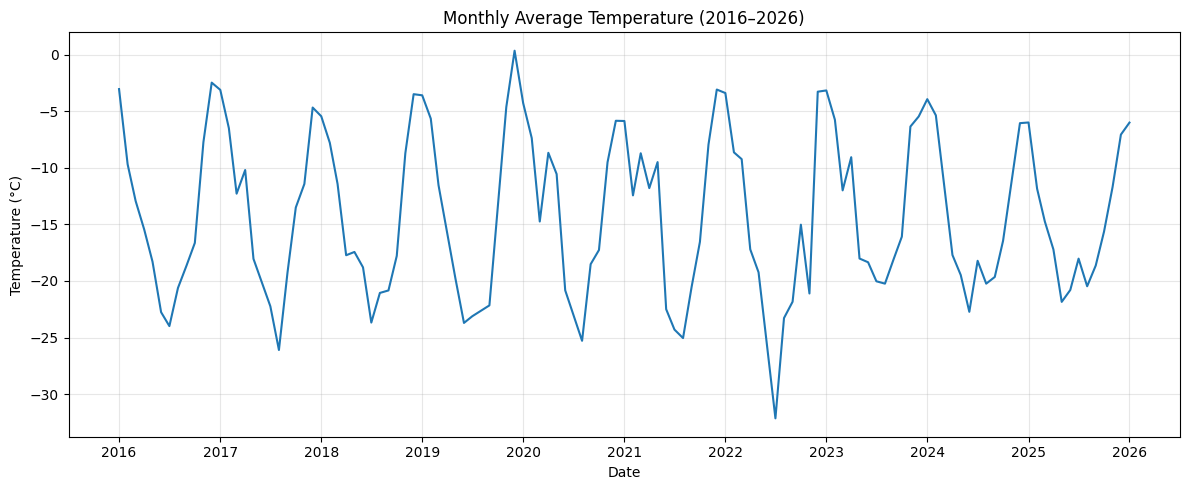

In [77]:
#Monthly Average Temperature
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_by_month['date'] = pd.to_datetime(df_by_month['date'])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_by_month['date'], df_by_month['value'])
ax.set_title('Monthly Average Temperature (2016–2026)')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

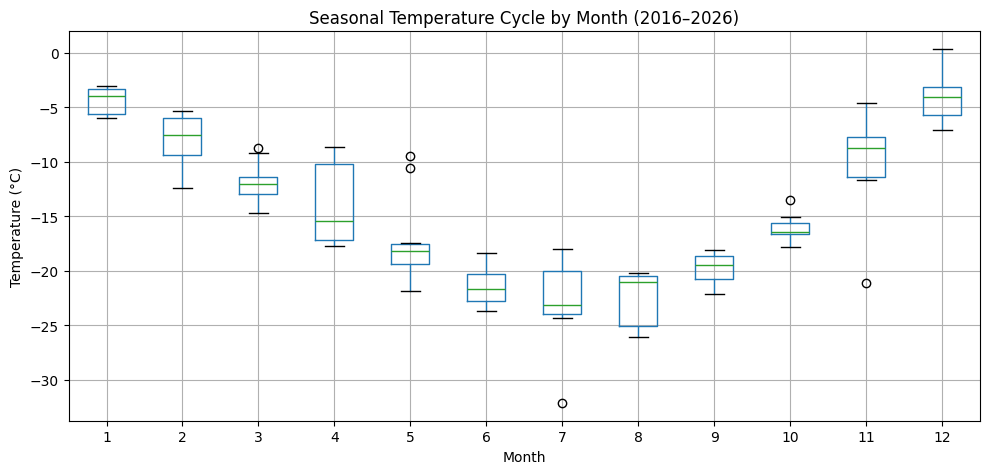

In [82]:
#Seasonal cycle by month (shows the summer/winter swing and how consistent it is year to year)

fig, ax = plt.subplots(figsize=(10, 5))
df_by_month.boxplot(column='value', by='month', ax=ax)
plt.suptitle('')
ax.set_title('Seasonal Temperature Cycle by Month (2016–2026)')
ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

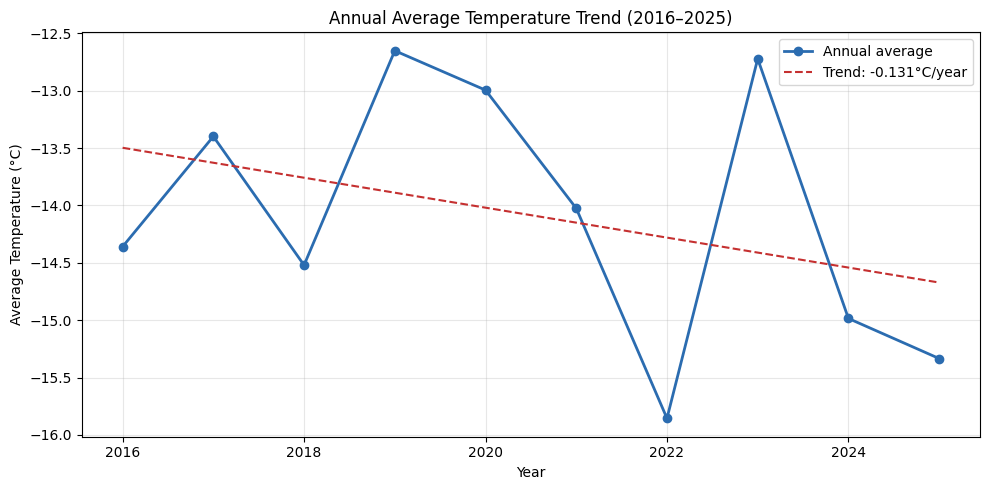

In [75]:
#Annual average trend line
import numpy as np

yearly_avg = df_by_month.groupby('year')['value'].mean().reset_index()
yearly_avg = yearly_avg[yearly_avg['year'] != 2026] #exclude 2026 as it only has 1 month

z = np.polyfit(yearly_avg['year'], yearly_avg['value'], 1)
trend = np.poly1d(z)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_avg['year'], yearly_avg['value'], marker='o', color='#2b6cb0', linewidth=2, label='Annual average')
ax.plot(yearly_avg['year'], trend(yearly_avg['year']), linestyle='--', color='#c53030', label=f'Trend: {z[0]:.3f}°C/year')
ax.set_title('Annual Average Temperature Trend (2016–2025)')
ax.set_xlabel('Year')
ax.set_ylabel('Average Temperature (°C)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

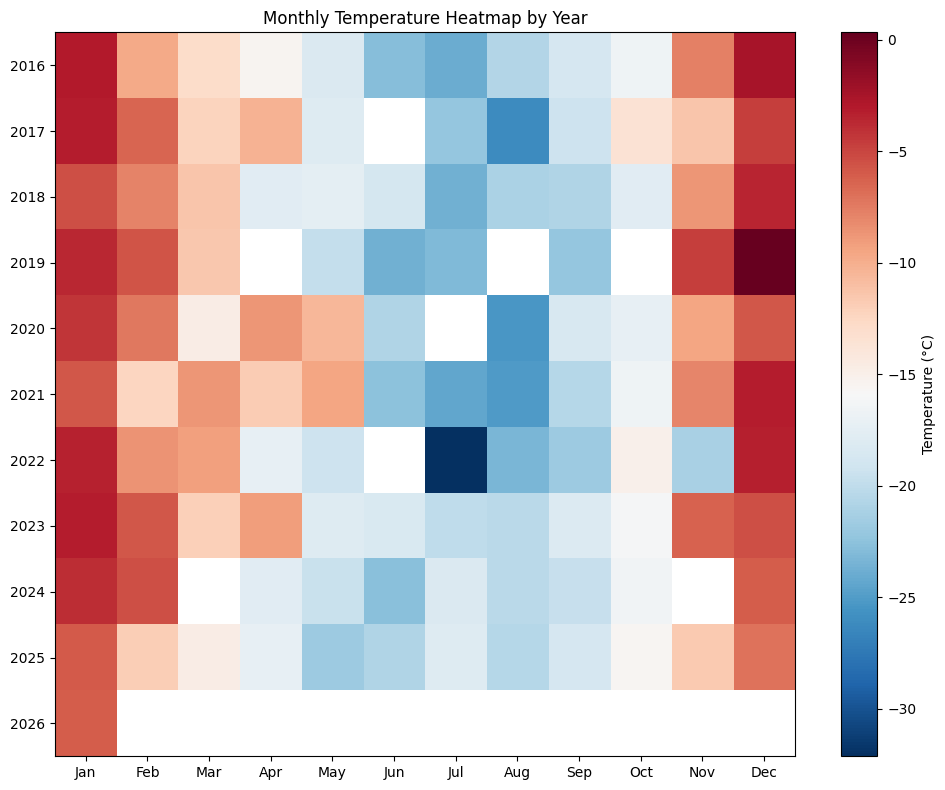

In [83]:
#Monthly Temperature Heatmap by Year
heatmap_data = df_by_month.pivot(index='year', columns='month', values='value')

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heatmap_data, cmap='RdBu_r', aspect='auto')
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_title('Monthly Temperature Heatmap by Year')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Temperature (°C)')
plt.tight_layout()
plt.show()

PENGUIN DATA

In [3]:
#Penguin Data Collection

raw_penguin = pd.read_csv("/content/Penguin data.csv", index_col = 0)
raw_penguin = raw_penguin.reset_index()


#Raw data Snapshot
print(f"1. Number of rows: {len(raw_penguin)}")
print(f"2. Columns: {raw_penguin.columns.tolist()}")
print(f"3. Missing values: \n{raw_penguin.isnull().sum().to_string()}")
print("\nDATA BEFORE CLEANING")
print(raw_penguin.head(5))

1. Number of rows: 5487
2. Columns: ['site_name', 'site_id', 'cammlr_region', 'longitude_epsg_4326', 'latitude_epsg_4326', 'common_name', 'day', 'month', 'year', 'season_starting', 'penguin_count', 'accuracy', 'count_type', 'vantage', 'reference']
3. Missing values: 
site_name                 0
site_id                   0
cammlr_region             0
longitude_epsg_4326       0
latitude_epsg_4326        0
common_name               0
day                    2143
month                  1510
year                      0
season_starting           0
penguin_count            23
accuracy                 23
count_type                0
vantage                 305
reference                 0

DATA BEFORE CLEANING
      site_name site_id cammlr_region  longitude_epsg_4326  \
0  Acuna Island    ACUN          48.2              -44.637   
1  Acuna Island    ACUN          48.2              -44.637   
2  Acuna Island    ACUN          48.2              -44.637   
3  Acuna Island    ACUN          48.2     

In [17]:
#Data Cleaning

#Drop unnecessary columns (day as we are looking into monthly data)
df_penguin_dropped = raw_penguin.drop(columns=['site_name','reference','cammlr_region', 'longitude_epsg_4326', 'latitude_epsg_4326', 'day', 'season_starting', 'accuracy', 'count_type','vantage'], axis=1)

#Only include penguin data after 2016
df_penguin_recent = df_penguin_dropped[df_penguin_dropped['year'] >= 2016].reset_index(drop=True)
df_penguin_recent.sort_values(by='year')


,site_id,common_name,month,year,penguin_count
1216,ZAWA,chinstrap penguin,NaN,2016,68.0
1207,YANK,gentoo penguin,12.0,2016,5677.0
1176,WATE,gentoo penguin,12.0,2016,3180.0
1175,WATE,gentoo penguin,12.0,2016,3115.0
1206,YANK,gentoo penguin,2.0,2016,2521.0
...,...,...,...,...,...
484,GEOR,chinstrap penguin,1.0,2026,114.0
494,GEOR,gentoo penguin,1.0,2026,2853.0
383,DOBE,gentoo penguin,1.0,2026,211.0
579,HUNT,chinstrap penguin,2.0,2026,450.0


In [23]:
#Fill in missing months

# flag which rows were originally missing — important to disclose in your methodology
df_penguin_recent['month_is_imputed'] = df_penguin_recent['month'].isna()
df_penguin_recent

'''
For the missing month, we're going to go with the approach of filling in the month mode for that same site_id (and ideally the same species).
Try site + species first (most specific), fall back to site-only if that combination has no known month, and fall back to the overall dataset's mode as a last resort
'''
# make sure the flag column is proper boolean, not string "true"/"false"
df_penguin_recent['month_is_imputed'] = df_penguin_recent['month_is_imputed'].astype(str).str.lower() == 'true'

# most specific: typical month for this site + species combo
site_species_mode = (
    df_penguin_recent[df_penguin_recent['month'].notna()]
    .groupby(['site_id', 'common_name'])['month']
    .agg(lambda x: x.mode().iloc[0])
)

# fallback: typical month for this site overall
site_mode = (
    df_penguin_recent[df_penguin_recent['month'].notna()]
    .groupby('site_id')['month']
    .agg(lambda x: x.mode().iloc[0])
)

# last-resort fallback: most common month across the whole dataset
overall_mode = df_penguin_recent['month'].mode().iloc[0]

def fill_month(row):
    if pd.notna(row['month']):
        return row['month']
    key = (row['site_id'], row['common_name'])
    if key in site_species_mode.index:
        return site_species_mode.loc[key]
    elif row['site_id'] in site_mode.index:
        return site_mode.loc[row['site_id']]
    else:
        return overall_mode

df_penguin_recent['month'] = df_penguin_recent.apply(fill_month, axis=1)


,site_id,common_name,month,year,penguin_count,month_is_imputed
0,ADAR,adelie penguin,12.0,2018,504332.0,False
1,ADAR,adelie penguin,12.0,2023,337361.0,False
2,AILS,chinstrap penguin,2.0,2020,3000.0,False
3,AITC,chinstrap penguin,12.0,2018,3797.0,False
4,AITC,gentoo penguin,12.0,2017,1704.0,False
...,...,...,...,...,...,...
1212,YANK,gentoo penguin,12.0,2024,5658.0,False
1213,YANK,gentoo penguin,12.0,2025,7518.0,False
1214,YANK,gentoo penguin,12.0,2025,6662.0,False
1215,YULE,emperor penguin,1.0,2019,1000.0,True


In [24]:
#drop duplicates (from 1217 to 1208 rows)
df_penguin_clean = df_penguin_recent.drop_duplicates()
df_penguin_clean

,site_id,common_name,month,year,penguin_count,month_is_imputed
0,ADAR,adelie penguin,12.0,2018,504332.0,False
1,ADAR,adelie penguin,12.0,2023,337361.0,False
2,AILS,chinstrap penguin,2.0,2020,3000.0,False
3,AITC,chinstrap penguin,12.0,2018,3797.0,False
4,AITC,gentoo penguin,12.0,2017,1704.0,False
...,...,...,...,...,...,...
1212,YANK,gentoo penguin,12.0,2024,5658.0,False
1213,YANK,gentoo penguin,12.0,2025,7518.0,False
1214,YANK,gentoo penguin,12.0,2025,6662.0,False
1215,YULE,emperor penguin,1.0,2019,1000.0,True


Visualization

In [25]:
species_colors = {
    'adelie penguin': '#4C72B0',
    'chinstrap penguin': '#DD8452',
    'gentoo penguin': '#55A868',
    'emperor penguin': '#8172B2',
    'macaroni penguin': '#C44E52'
}

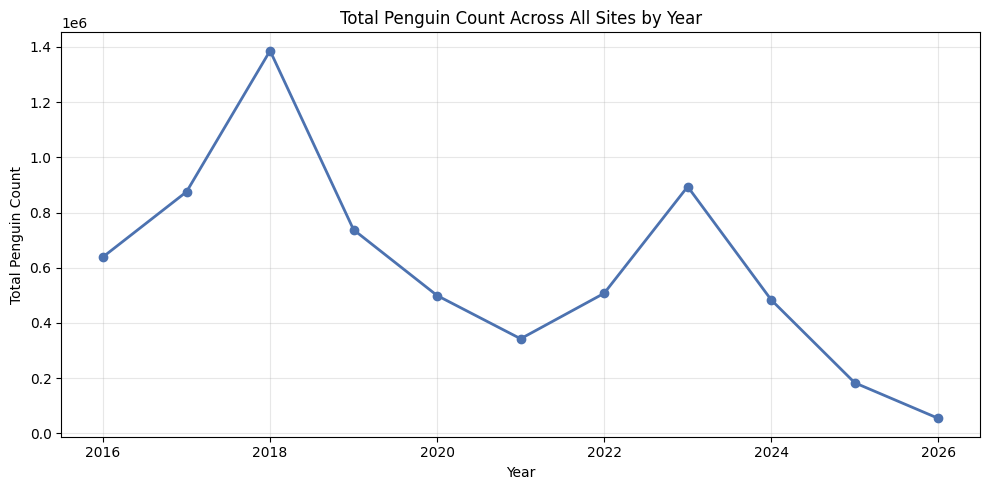

In [28]:
#Total Penguin Count Across All Sites by Year
yearly_total = df_penguin_clean.groupby('year')['penguin_count'].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_total['year'], yearly_total['penguin_count'], marker='o', color='#4C72B0', linewidth=2)
ax.set_title('Total Penguin Count Across All Sites by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Total Penguin Count')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

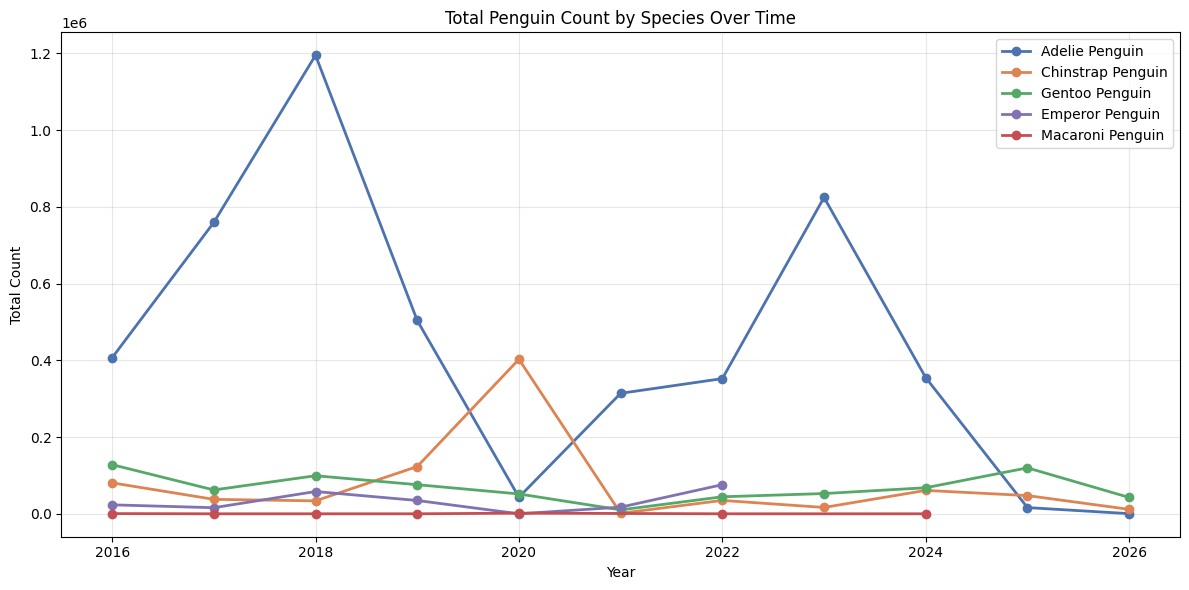

In [29]:
#Total Penguin Count by Species Over Time
species_yearly = df_penguin_clean.groupby(['year', 'common_name'])['penguin_count'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
for species, color in species_colors.items():
    data = species_yearly[species_yearly['common_name'] == species]
    if not data.empty:
        ax.plot(data['year'], data['penguin_count'], marker='o', label=species.title(), color=color, linewidth=2)

ax.set_title('Total Penguin Count by Species Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Total Count')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

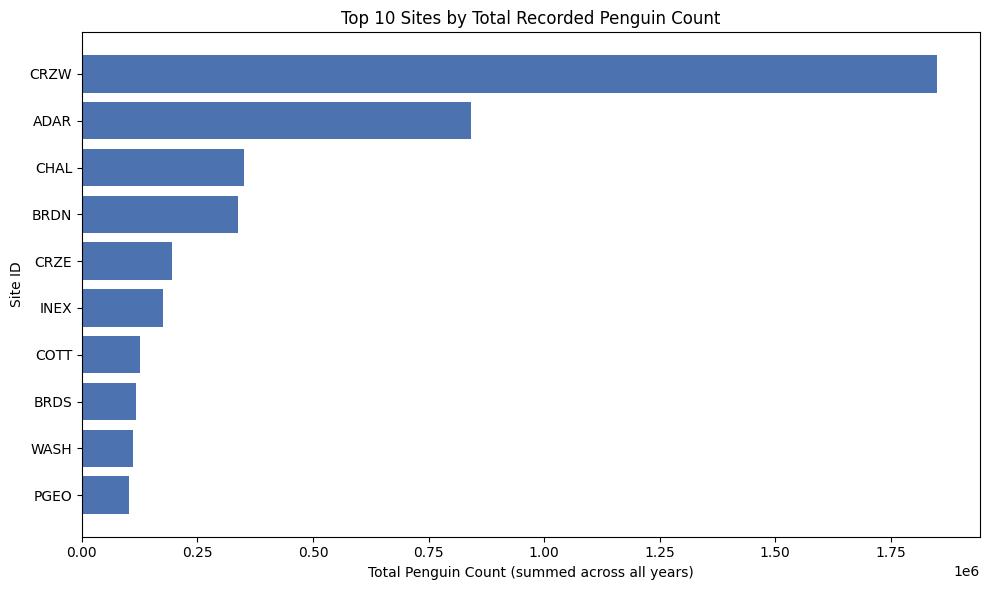

In [30]:
#Top 10 Sites by Total Recorded Penguin Count
top_sites = df_penguin_clean.groupby('site_id')['penguin_count'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_sites.index[::-1], top_sites.values[::-1], color='#4C72B0')
ax.set_title('Top 10 Sites by Total Recorded Penguin Count')
ax.set_xlabel('Total Penguin Count (summed across all years)')
ax.set_ylabel('Site ID')
plt.tight_layout()
plt.show()

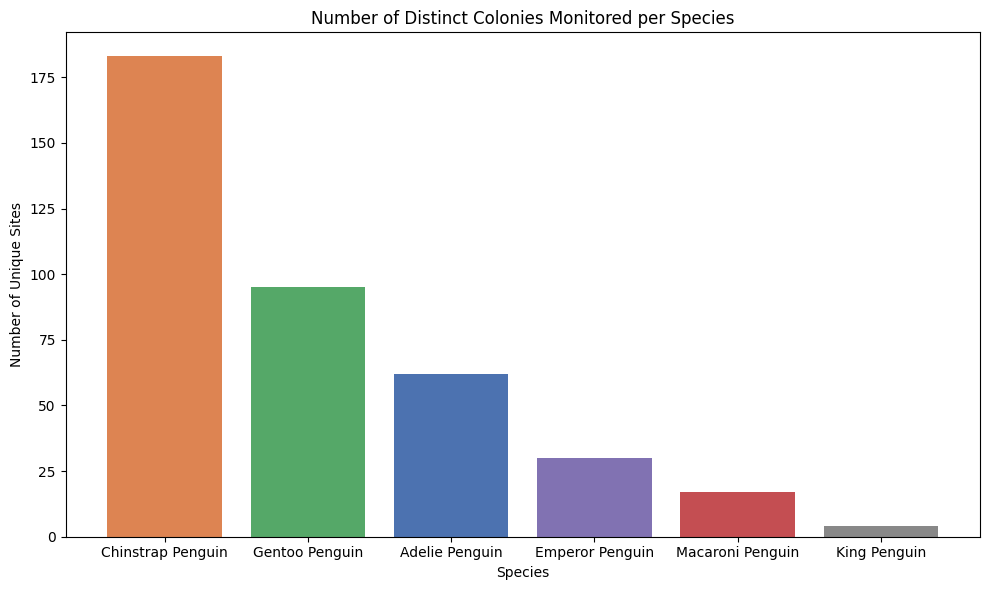

In [33]:
#Number of Distinct Colonies Monitored per Species
site_counts = df_penguin_clean.groupby('common_name')['site_id'].nunique().sort_values(ascending=False)
colors = [species_colors.get(sp, '#888888') for sp in site_counts.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar([s.title() for s in site_counts.index], site_counts.values, color=colors)
ax.set_title('Number of Distinct Colonies Monitored per Species')
ax.set_xlabel('Species')
ax.set_ylabel('Number of Unique Sites')
plt.tight_layout()
plt.show()

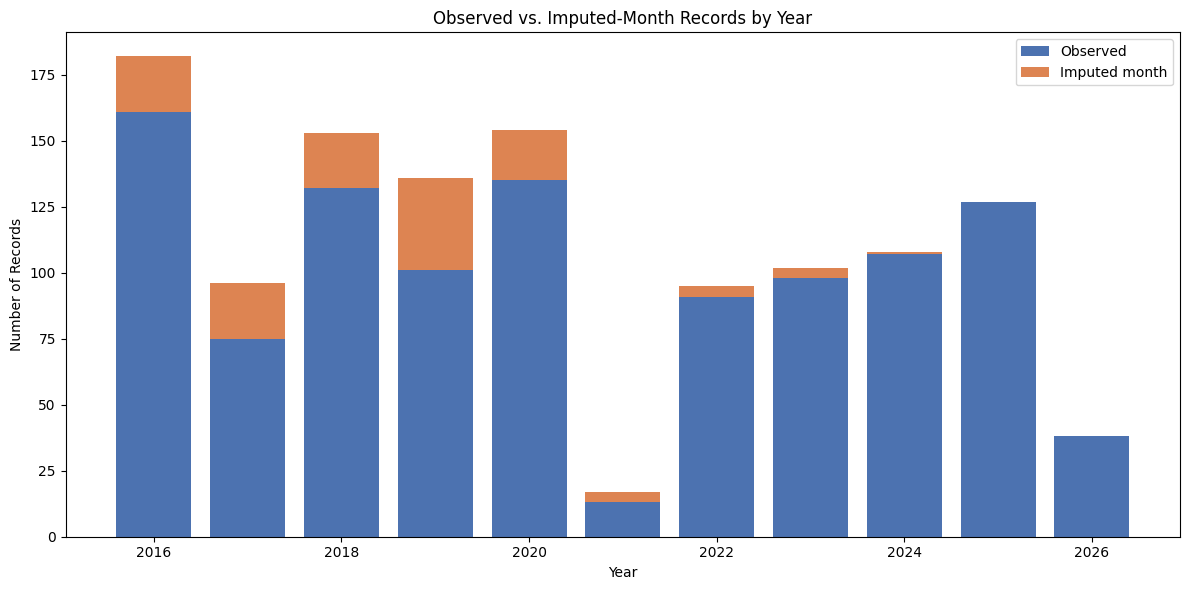

In [34]:
#Observed vs. Imputed-Month Records by Year
imputation_by_year = df_penguin_clean.groupby(['year', 'month_is_imputed']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(imputation_by_year.index, imputation_by_year.get(False, 0), label='Observed', color='#4C72B0')
ax.bar(imputation_by_year.index, imputation_by_year.get(True, 0), bottom=imputation_by_year.get(False, 0),
       label='Imputed month', color='#DD8452')
ax.set_title('Observed vs. Imputed-Month Records by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Records')
ax.legend()
plt.tight_layout()
plt.show()

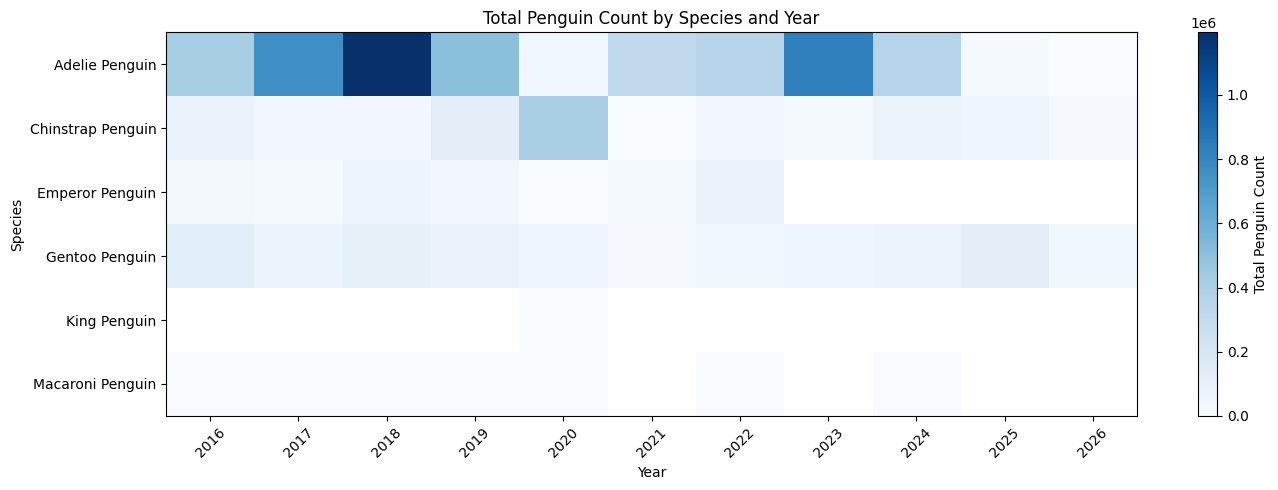

In [35]:
#Total Penguin Count by Species and Year
heatmap_data = df_penguin_clean.pivot_table(
    index='common_name',
    columns='year',
    values='penguin_count',
    aggfunc='sum'
)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heatmap_data, cmap='Blues', aspect='auto')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels([s.title() for s in heatmap_data.index])

ax.set_title('Total Penguin Count by Species and Year')
ax.set_xlabel('Year')
ax.set_ylabel('Species')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Total Penguin Count')

plt.tight_layout()
plt.show()